In [1]:
import scanpy as sc
import pandas as pd
import numpy as np

In [2]:
import os
import anndata as ad

In [3]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

In [4]:
import seaborn as sns

In [5]:
from tripso.Evaluate.downstream import calculate_gene_significance, plot_top_genes


# Cosine similarity - IKZF1

In [6]:
def load_adata(run, output_name = 'global'):
    holder = []
    base_path = 'tripso_reproducibility/04.5_HSC_post_qc'
    

    for t in ['train', 'val', 'test']:
        target_path = 'DCA_lymphoid/IKZF1_repeat'
        dataset1 = 'cd34_proB'
        dataset2 = 'mnc_proB'
        filename = f'gene_to_GP_IKZF1_cosine_similarity_{t}_set.h5ad'
        
        holder.append(
            sc.read_h5ad(os.path.join(base_path, f'{run}_by_study/output_{output_name}', target_path, dataset1, filename))
        )
        
        holder.append(
            sc.read_h5ad(os.path.join(base_path, f'{run}_by_study/output_{output_name}', target_path, dataset2, filename))
        )
        
    adata = ad.concat(holder)    
    
    return adata


In [7]:
run1 = load_adata('run_1')
run2 = load_adata('run_2')
run3 = load_adata('run_3')

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


In [8]:
adata = sc.AnnData(
    X = (run1.X + run2.X + run3.X)/3,
    obs = run1.obs,
    var = run1.var
)

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


In [9]:
adata.obs = adata.obs.set_index('idx')

In [10]:
# update cell type labels
del adata.obs['cell_type']

# use updated labels
cd34 = pd.read_csv('tripso_reproducibility/04.5_HSC_post_qc/data/raw/CD34_annotations.csv', index_col = 0)
mnc = pd.read_csv('tripso_reproducibility/04.5_HSC_post_qc/data/raw/MNC_cell_types.csv', index_col = 0)
cell_labels = pd.concat([cd34, mnc])

adata.obs = adata.obs.join(cell_labels)

In [11]:
# map ensembl to gene name 
from geneformer import ENSEMBL_DICTIONARY_FILE
name_to_ens = pd.read_pickle(ENSEMBL_DICTIONARY_FILE)
name_df = pd.DataFrame(
            list(name_to_ens.items()), columns=['gene', 'ensembl_id']
        )

convert_df = name_df[name_df['ensembl_id'].isin(adata.var_names)]

gpdb_symbol = pd.read_csv('tripso_reproducibility/04.5_HSC_post_qc/gp_nw_all.csv')
# gpdb_symbol = pd.read_csv('tripso_reproducibility/02.1_benchmarking_repeat/gpdb_progeny_200.csv')

convert_df = convert_df[convert_df['gene'].isin(gpdb_symbol['GP_IKZF1'].values)]

In [12]:
adata.var = adata.var.join(convert_df.set_index('ensembl_id'))

In [13]:
adata.var = adata.var.set_index('gene')

In [14]:
adata = adata[adata.obs['tissue'].str.contains('ABM|PBM') | 
              (adata.obs['tissue'] == 'FL')]

In [15]:
adata.obs['tissue_binary'] = np.where(
    adata.obs['tissue'].isin(['YS', 'FL', 'FBM', 'CB']),
    'Prenatal', 
    'Postnatal'
)


/tmp/ipykernel_2136733/3171038059.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['tissue_binary'] = np.where(


In [16]:
adata.obs['cell_type'].value_counts()

cell_type
13_Pro_B            9595
12_Cycling_Pro_B    5400
10_CLP              1521
11_PreProB           588
12_Pro_B             389
11_Cycling_Pro_B     234
Name: count, dtype: int64

In [17]:
adata1 = adata[
    adata.obs['cell_type'].str.contains('_Pro_B')
    # adata.var.index != 'HBG1'
].copy()

In [18]:
adata1

AnnData object with n_obs × n_vars = 15618 × 53
    obs: 'length', 'runid_mrna_sample', 'age', 'sorting', 'sex', 'tissue', 'age_general', 'phase', 'donor_tissue', 'source', 'tissue_source', 'n_counts', 'study', 'donor', 'age_group', 'cell_type_stage', 'tissue_cell_cat', 'batch_key', 'cell_type_id', 'source_id', 'batch_key_id', 'cell_type', 'tissue_binary'

In [19]:
res = calculate_gene_significance(
    adata1,
    obs_col="tissue_binary",
    obs_value_ref="Prenatal",
    obs_value_query="Postnatal",
    adata_gene_threshold=0.9, 
)

/nfs/team361/mm58/tripso/tripso/Evaluate/downstream.py:2196: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1, 0].set_yticklabels(yticklabels)
/nfs/team361/mm58/tripso/tripso/Evaluate/downstream.py:2281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1, 1].set_yticklabels(yticklabels)


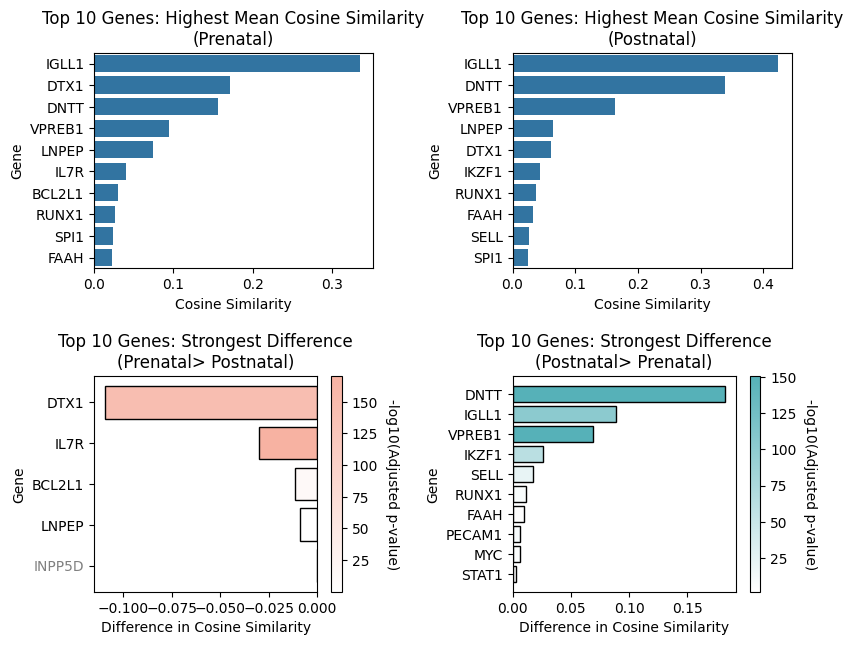

In [20]:
plot_top_genes(
    res,
    obs_value_ref="Prenatal",
    obs_value_query="Postnatal",
    show_significance=False,
    color_scheme='significance',
    significance_palette = ['#f7b2a2', '#56b1b8'],
    palette_as_gradient=True,   # uses the two colors to build gradients
    topn=10,
    figsize = (9,7),
    save_to = 'pro_B_FL.pdf'
)



# Cycling proB only

In [21]:
adata2 = adata[
    adata.obs['cell_type'].str.contains('Cycling_Pro_B'),
    adata.var.index != 'HBG1'
].copy()

In [22]:
adata2

AnnData object with n_obs × n_vars = 5634 × 52
    obs: 'length', 'runid_mrna_sample', 'age', 'sorting', 'sex', 'tissue', 'age_general', 'phase', 'donor_tissue', 'source', 'tissue_source', 'n_counts', 'study', 'donor', 'age_group', 'cell_type_stage', 'tissue_cell_cat', 'batch_key', 'cell_type_id', 'source_id', 'batch_key_id', 'cell_type', 'tissue_binary'

In [23]:
res = calculate_gene_significance(
    adata2,
    obs_col="tissue_binary",
    obs_value_ref="Prenatal",
    obs_value_query="Postnatal",
    adata_gene_threshold=0.9, 
)

/nfs/team361/mm58/tripso/tripso/Evaluate/downstream.py:2196: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1, 0].set_yticklabels(yticklabels)
/nfs/team361/mm58/tripso/tripso/Evaluate/downstream.py:2281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1, 1].set_yticklabels(yticklabels)


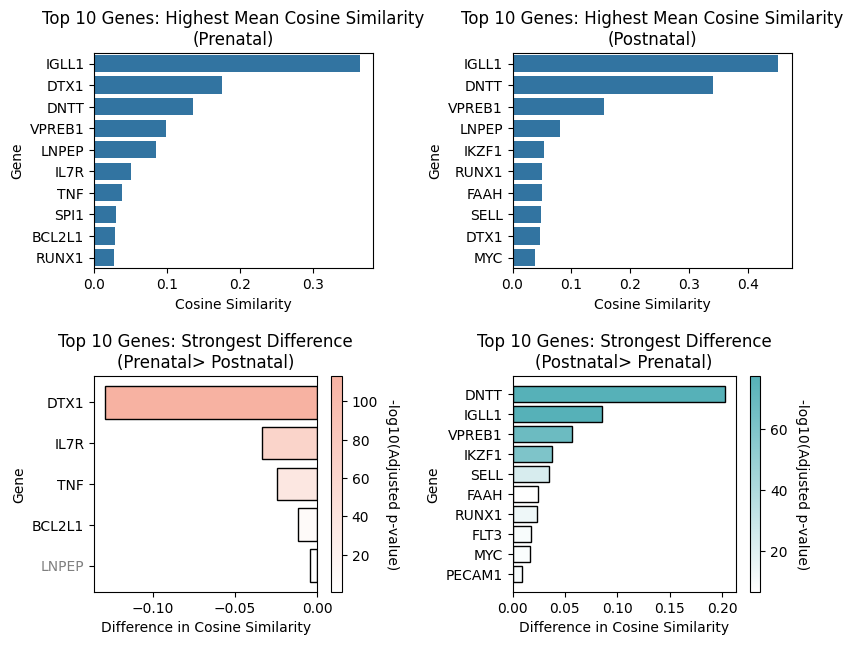

In [24]:
plot_top_genes(
    res,
    obs_value_ref="Prenatal",
    obs_value_query="Postnatal",
    show_significance=False,
    color_scheme='significance',
    significance_palette = ['#f7b2a2', '#56b1b8'],
    palette_as_gradient=True,   # uses the two colors to build gradients
    topn=10,
    figsize = (9,7),
    save_to = 'pro_B_cycling_FL.pdf'
)



# proB only

In [25]:
adata3 = adata[
    adata.obs['cell_type'].isin(['12_Pro_B', '13_Pro_B'])
    # adata.var.index != 'HBG1'
].copy()

In [26]:
res = calculate_gene_significance(
    adata3,
    obs_col="tissue_binary",
    obs_value_ref="Prenatal",
    obs_value_query="Postnatal",
    adata_gene_threshold=0.9, 
)

/nfs/team361/mm58/tripso/tripso/Evaluate/downstream.py:2196: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1, 0].set_yticklabels(yticklabels)
/nfs/team361/mm58/tripso/tripso/Evaluate/downstream.py:2281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1, 1].set_yticklabels(yticklabels)


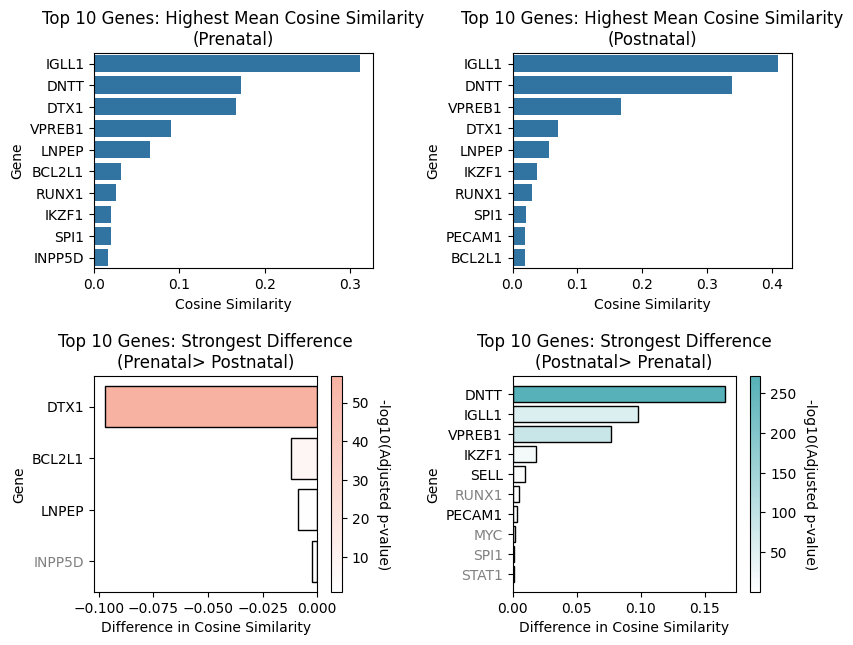

In [27]:
plot_top_genes(
    res,
    obs_value_ref="Prenatal",
    obs_value_query="Postnatal",
    show_significance=False,
    color_scheme='significance',
    significance_palette = ['#f7b2a2', '#56b1b8'],
    palette_as_gradient=True,   # uses the two colors to build gradients
    topn=10,
    figsize = (9,7),
    save_to = 'pro_B_noncyling_FL.pdf'
)

